## **Lviv Food Places: Data Cleaning & Feature Engineering**

**Source:** Google Maps restaurant data enriched with Glovo availability

**Goal:** Filter, clean, standardize, and enrich restaurant-level data for Lviv city.

**Output:** Analysis-ready dataset for market analysis and Tableau dashboards.

## **Project Overview**

This notebook focuses on cleaning and feature engineering for a food places dataset in Lviv.  
The raw dataset was collected from Google Maps and enriched with Glovo availability information.

The dataset contains restaurant-level information such as location, rating, number of reviews, price level, opening hours, Google Maps attributes, and Glovo availability.

The goal of this stage is to prepare an analysis-ready dataset that can be used for marketplace, delivery coverage, restaurant segmentation, and geo-analytics.

In [1]:
!pip install geopandas shapely osmnx --quiet

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import re

from google.colab import drive, files

import geopandas as gpd
import osmnx as ox

from shapely.geometry import Point

## **1. Setup & Data Loading**


In [3]:
# Mount Google Drive and navigate to the project folder

In [4]:
# Quick sanity check
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Dataset shape: 1,017 rows × 17 columns

Column types:
place_id            object
found_name          object
address             object
latitude           float64
longitude          float64
rating             float64
reviews_count      float64
price_level        float64
maps_url            object
opening_hours       object
types_details       object
wheelchair          object
delivery            object
takeout             object
dine_in             object
glovo_available       bool
original_name       object
dtype: object

Duplicate rows: 0


**Dataset Columns Overview**

The raw dataset contains restaurant information collected from Google Maps and enriched with Glovo availability data.

| Column | Type | Description |
|----------|----------|----------|
| place_id | object | Unique Google Maps place identifier |
| found_name | object | Restaurant name from Google Maps |
| address | object | Full restaurant address |
| latitude | float64 | Latitude coordinate |
| longitude | float64 | Longitude coordinate |
| rating | float64 | Average Google Maps rating (1–5) |
| reviews_count | float64 | Number of Google Maps reviews |
| price_level | float64 | Google Maps price category (1–4) |
| maps_url | object | Direct link to Google Maps |
| opening_hours | object | Raw weekly opening schedule |
| types_details | object | Google Maps place type tags |
| wheelchair | object | Wheelchair accessibility information |
| delivery | object | Delivery availability |
| takeout | object | Takeout availability |
| dine_in | object | Dine-in availability |
| glovo_available | bool | Indicates whether the restaurant is available on Glovo |
| original_name | object | Original restaurant name from Glovo |

## **2. Column Type Overview**

In [5]:
numeric_columns = df.select_dtypes(include=["float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns
bool_columns = df.select_dtypes(include=["bool"]).columns

print(f"\nNumeric columns    ({len(numeric_columns)}): {list(numeric_columns)}")
print(f"Categorical columns({len(categorical_columns)}): {list(categorical_columns)}")
print(f"Boolean columns    ({len(bool_columns)}): {list(bool_columns)}")


Numeric columns    (5): ['latitude', 'longitude', 'rating', 'reviews_count', 'price_level']
Categorical columns(11): ['place_id', 'found_name', 'address', 'maps_url', 'opening_hours', 'types_details', 'wheelchair', 'delivery', 'takeout', 'dine_in', 'original_name']
Boolean columns    (1): ['glovo_available']


**Data Types Summary**

The dataset contains:
- 11 categorical (object) columns
- 5 service-related categorical flags (object)
- 5 numeric (float64) features
- 1 boolean feature (bool)

The following sections focus on cleaning, standardizing, and enriching these fields to create an analysis-ready dataset.

## **3. Geographic Filtering (Lviv city only)**

The raw dataset includes places from Lviv and nearby suburban areas.

To keep the analysis city-specific, places are filtered using official Lviv district polygons from **OpenStreetMap** instead of relying on address text.

In [6]:
# Download Lviv districts directly from OpenStreetMap
districts_gdf = ox.features_from_place(
    "Львів, Україна",
    tags={"boundary": "administrative", "admin_level": "9"}
)

print(f"Found: {len(districts_gdf)} features")
print(f"Columns: {districts_gdf.columns.tolist()}")
print(districts_gdf[["name"]].dropna().head(20))

Found: 32 features
Columns: ['geometry', 'admin_level', 'alt_name:ar', 'alt_name:de', 'alt_name:hr', 'katotth', 'koatuu', 'name', 'name:ar', 'name:az', 'name:be', 'name:bg', 'name:br', 'name:ca', 'name:crh', 'name:cs', 'name:cv', 'name:de', 'name:en', 'name:eo', 'name:es', 'name:et', 'name:eu', 'name:fa', 'name:fi', 'name:fr', 'name:he', 'name:hr', 'name:hu', 'name:hy', 'name:id', 'name:io', 'name:it', 'name:ja', 'name:ka', 'name:ko', 'name:lt', 'name:lv', 'name:mk', 'name:mr', 'name:ms', 'name:nl', 'name:nn', 'name:os', 'name:pl', 'name:prefix', 'name:pt', 'name:ro', 'name:ru', 'name:sk', 'name:sl', 'name:sr', 'name:sv', 'name:szl', 'name:tr', 'name:uk', 'name:vi', 'name:zh', 'old_name:ko', 'old_name:lv', 'place', 'population', 'postal_code', 'start_date', 'website', 'wikidata', 'wikipedia', 'wikipedia:pl', 'boundary', 'ref', 'type', 'ISO3166-2', 'name:be-tarask', 'name:nan', 'name:no', 'name:pnb', 'name:rue', 'name:sco', 'name:sh', 'name:war', 'name:zh-Hans', 'name:zh-Hant', 'ref:en'

In [7]:
# Filter to Lviv city districts only
lviv_districts = [
    "Галицький район",
    "Личаківський район",
    "Сихівський район",
    "Франківський район",
    "Залізничний район",
    "Шевченківський район",
]

districts_gdf = districts_gdf[
    districts_gdf["name"].isin(lviv_districts)][["name", "geometry"]].copy()

In [8]:
# Transliterate district names to Latin
districts_gdf["district"] = (
    districts_gdf["name"]
    .str.replace(" район", "")
    .map({
        "Галицький":      "Halytskyi",
        "Личаківський":   "Lychakivskyi",
        "Сихівський":     "Sykhivskyi",
        "Франківський":   "Frankivskyi",
        "Залізничний":    "Zaliznychnyi",
        "Шевченківський": "Shevchenkivskyi",
    })
)

districts_gdf = districts_gdf.set_crs("EPSG:4326", allow_override=True)
print(f"Districts loaded: {len(districts_gdf)}")

Districts loaded: 6


In [9]:
# Convert all raw places to GeoDataFrame
all_places_gdf = gpd.GeoDataFrame(
    df,
    geometry=[
        Point(lon, lat)
        for lon, lat in zip(df["longitude"], df["latitude"])
    ],
    crs="EPSG:4326"
)

# Spatial join — keep only points within Lviv districts
places_with_district = gpd.sjoin(
    all_places_gdf,
    districts_gdf[["district", "geometry"]],
    how="inner",
    predicate="within"
)

lviv_df = df.loc[places_with_district.index].copy()
lviv_df["district"] = places_with_district["district"].values

print(f"Before spatial filter : {df.shape[0]:,} rows")
print(f"After  spatial filter : {lviv_df.shape[0]:,} rows")
print(f"Removed               : {df.shape[0] - lviv_df.shape[0]} out-of-city places")
print("\nPlaces per district:")
print(lviv_df["district"].value_counts())

Before spatial filter : 1,017 rows
After  spatial filter : 961 rows
Removed               : 56 out-of-city places

Places per district:
district
Frankivskyi        213
Sykhivskyi         191
Shevchenkivskyi    155
Zaliznychnyi       153
Halytskyi          142
Lychakivskyi       107
Name: count, dtype: int64


## **4. Opening Hours Parsing**

Opening hours are stored as long text strings with weekday-level schedules.

To make this information usable for analysis, the raw schedule is transformed into structured features:
- standard opening hours,
- days with different schedules,
- closed days.

In [10]:
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

In [11]:
def get_closed_days(text: str) -> str | None:
    """
    Return a comma-separated list of days when the place is closed,
    or 'None' if it operates every day.
    Returns None if the opening_hours field is missing.
    """
    if pd.isna(text):
        return None

    closed = [day for day in days if f"{day}: Closed" in text]
    return ", ".join(closed) if closed else None

In [12]:
def parse_schedule(text: str) -> pd.Series:
    """
    Parse the raw opening_hours string into two derived fields:
    - standard_opening_hours  : the most common daily schedule
    - different_schedule_details : pipe-separated exceptions (days that differ)

    '24 hours' entries are normalised to '00:00 - 23:59'.
    Returns (None, None) when the input is missing.
    """
    if pd.isna(text):
        return pd.Series([None, None])

    # Build a day - hours mapping
    schedule = {}
    for day in days:
        match = re.search(rf"{day}:\s*([^|]+)", text)
        if match:
            hours = match.group(1).strip()
            hours = hours.replace("Open 24 hours", "00:00 - 23:59")
            schedule[day] = hours

    if not schedule:
        return pd.Series([None, None])

    # The most frequent schedule is treated as the "standard"
    most_common = max(set(schedule.values()), key=list(schedule.values()).count)

    # Collect days that deviate from the standard schedule
    exceptions = [
        f"{day}: {hours}"
        for day, hours in schedule.items()
        if hours != most_common
    ]
    different_schedule_details = " | ".join(exceptions) if exceptions else None

    return pd.Series([most_common, different_schedule_details])

In [13]:
# Apply both parsers and drop the raw column
lviv_df["closed_days"] = lviv_df["opening_hours"].apply(get_closed_days)

lviv_df[["standard_opening_hours", "different_schedule_details"]] = (
    lviv_df["opening_hours"].apply(parse_schedule)
)

In [14]:
lviv_df = lviv_df.drop("opening_hours", axis=1)

## **5. Business Model Classification**



Google Maps place types are too generic for marketplace analysis.

A custom business model classification is created to separate restaurants, cafes, bakeries, hotel restaurants, takeaway spots, and delivery-only formats.

In [15]:
# Remove grocery chains, supermarkets, and other non-restaurant businesses
# that ended up in the dataset due to broad Google Maps category queries

exclude_keywords = [
    "arsen", "silpo", "сільпо", "atb", "auchan", "metro",
    "rukavychka", "близенько", "spar", "sim-23",
    "курси", "сервіс", "фудхол", "тест", "покупон", "знижки", "акції",
    "test company", "tbc", "александр мусатов", "спартак спортивно",
    "акваpark", "akvapark"
]

lviv_df = lviv_df[
    ~lviv_df["found_name"]
    .str.lower()
    .str.contains("|".join(exclude_keywords), na=False)
].copy()

In [16]:
# Normalise the types_details field: collapse extra commas and whitespace
lviv_df["types_details"] = (
    lviv_df["types_details"]
    .str.replace(r",\s*,", ",", regex=True)
    .str.replace(r"^,\s*|\s*,$", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [17]:
def detect_business_model(row: pd.Series) -> str:
    """
    Classify each place into a business model category based on:
      - keywords in the name
      - Google Maps type tags
      - delivery / takeout / dine-in flags
      - Glovo availability
    """
    name            = str(row["found_name"]).lower()
    types           = str(row["types_details"]).lower()
    delivery        = row["delivery"]
    takeout         = row["takeout"]
    dine_in         = row["dine_in"]
    glovo_available = row["glovo_available"]

    delivery_keywords = [
        "доставка", "delivery", "dark kitchen", "cloud kitchen",
        "take away", "takeaway", "express"
    ]

    if any(word in name for word in delivery_keywords):
        return "Delivery Only / Dark Kitchen"

    if "lodging" in types or "hotel" in types:
        return "Hotel Restaurant"

    if "bakery" in types:
        return "Bakery"

    if "cafe" in types:
        return "Cafe"

    if (delivery is True or glovo_available is True) and dine_in is not True:
        return "Delivery Only / Dark Kitchen"

    if takeout is True and dine_in is not True:
        return "Takeaway Spot"

    if "restaurant" in types and dine_in is True and (delivery is True or glovo_available is True):
        return "Restaurant with Delivery"

    if "restaurant" in types and dine_in is True:
        return "Dine-in Restaurant"

    if "restaurant" in types:
        return "Restaurant"

    return "Other"

In [18]:
lviv_df["business_model"] = lviv_df.apply(detect_business_model, axis=1)

print("\nBusiness model distribution:\n")
print(lviv_df["business_model"].value_counts())


Business model distribution:

business_model
Restaurant with Delivery        407
Dine-in Restaurant              125
Delivery Only / Dark Kitchen    106
Cafe                             90
Bakery                           71
Restaurant                       55
Takeaway Spot                    54
Hotel Restaurant                 27
Name: count, dtype: int64


## **6. Cuisine Type Detection**

Cuisine type is not directly available from Google Maps.  

It is derived from restaurant names, Glovo names, and Google Maps type descriptions using keyword-based multi-label classification.

In [19]:
# Keyword lists for each cuisine category.
cuisine_keywords = {
    "Fast Food"        : ["fast food", "fast", "mcdonald", "mcdrive", "kfc", "hot dog",
                          "hotdog", "dogers", "хот-дог", "dog", "cheburek", "chebureky",
                          "чебур", "sandwich"],
    "American"         : ["american", "poke", "fugazzeta"],
    "Burgers"          : ["burger", "бургер", "burher"],
    "International"    : ["fusion", "international", "food court", "world", "daily"],
    "Kebab"            : ["shawarma", "шаур", "doner", "kebab", "кебаб", "shaur"],
    "Pizza"            : ["pizza", "піца", "pizzeria", "pizz", "celent", "pitse", "pitsa"],
    "Asian"            : ["asian", "asia", "wok", "ramen", "рамен", "bao", "thai",
                          "pho", "noodle", "red monkey", "kytays", "китайськ", "tayvans",
                          "тайванськ", "chinese", "taiwan", "vietnam", "вʼєтнам"],
    "Breakfast"        : ["breakfast", "brunch", "снідан"],
    "Ukrainian"        : ["ukrain", "україн", "borsch", "борщ", "варени", "galy",
                          "oselya", "галицьк", "козак", "микола", "козац", "шинок",
                          "пирі", "shynok", "kolyba", "ukra", "lwowska", "lvivska",
                          "skatertyn", "повітр", "hopak", "гопак", "kryivka", "криївк",
                          "sadyba", "садиб", "sloboda", "slibida", "слобод", "lemkivs",
                          "лемківськ", "varenyk", "hostyna"],
    "Sushi"            : ["sush", "суші", "рол", "япон", "roll", "banzay", "маомі", "maomi"],
    "Italian"          : ["italian", "pasta", "італі", "trattoria", "osteria", "famiglia",
                          "ristorante", "luigi", "mario"],
    "European"         : ["european", "європ"],
    "Healthy Food"     : ["healthy", "salad", "fit", "vegan", "vegetarian", "organic", "tomat"],
    "Bakery"           : ["bakery", "bake", "croissant", "круасан", "bread", "пекарн",
                          "pekarny", "pyrizh", "bulka", "baguette", "briosh", "brioche",
                          "simeyna", "ім'яна"],
    "Desserts & Coffee": ["dessert", "десерт", "кондитер", "cake", "pastry", "macaron",
                          "ice cream", "coffee", "cafe", "чай", "espresso", "roastery",
                          "кава", "кавяр", "кав'яр", "coffee lab", "baklava", "shoco"],
    "Georgian"         : ["georgian", "хачапур", "khachapuri", "хінкал", "hinkal", "mangal",
                          "мангал", "шашлик", "shashlyk", "shashlik", "грузин", "кавказ",
                          "caucas", "lyulya", "lulya", "люля", "aragvi"],
    "Grill"            : ["grill", "гриль", "bbq", "b.q", "b.b.q", "steak", "мясо",
                          "мʼясо", "м'ясо", "reber", "re:bro", "rebra", "rib", "ребер",
                          "meat", "m'yas", "zharovn", "жаровн"],
    "Bistro"           : ["bistro", "бістро", "їдальн", "tempo", "yidal", "buffet"],
    "Pub & Craft Beer" : ["pub", "craft", "beer", "taproom", "brew", "паб", "крафт",
                          "pyvovarn", "пивоварн", "stargorod"],
}

# Hotel-linked names default to a breakfast/european profile
hotel_keywords = [
    "hotel", "готель", "hostel", "inn", "spa", "resort",
    "eney", "lr hotel", "grand hotel", "taurus", "swiss hotel"
]

In [20]:
def detect_cuisines(text: str) -> str | None:
    """
    Return a pipe-separated string of cuisine categories detected
    in the given text (e.g. 'Pizza | Italian').

    Falls back to 'Breakfast | European' for hotel venues,
    and 'Other' when no keywords match.
    """
    if pd.isna(text):
        return None

    text = text.lower()

    # Hotel restaurants share a generic profile
    if any(x in text for x in hotel_keywords):
        return "Breakfast | European"

    found = []
    for cuisine, keywords in cuisine_keywords.items():
        if any(keyword in text for keyword in keywords):
            found.append(cuisine)

    if "bakery" in text:
        found.append("Bakery")

    # Deduplicate and sort alphabetically for consistency
    found = sorted(set(found))

    return " | ".join(found) if found else "Other"

In [21]:
# Build a single search text field combining name and type information
lviv_df["search_text"] = (
    lviv_df["found_name"].fillna("") + " " +
    lviv_df["original_name"].fillna("") + " " +
    lviv_df["types_details"].fillna("")
).str.lower()

lviv_df["cuisine_type"] = lviv_df["search_text"].apply(detect_cuisines)

print("\nCuisine type distribution:")
print(lviv_df["cuisine_type"].value_counts())


Cuisine type distribution:
cuisine_type
Other                                       272
Pizza                                       103
Kebab                                        94
Desserts & Coffee                            79
Bakery | Desserts & Coffee                   61
Sushi                                        40
Fast Food                                    38
Breakfast | European                         23
Grill                                        23
Bistro                                       22
Ukrainian                                    21
Georgian                                     18
Bakery                                       18
Asian                                        18
Burgers                                      12
Healthy Food                                  9
Pizza | Sushi                                 8
Pub & Craft Beer                              7
Georgian | Kebab                              7
Bistro | Desserts & Coffee                    6

In [22]:
# Inspect what's actually in the "Other" bucket
other_df = lviv_df[lviv_df["cuisine_type"] == "Other"]

print(f"Other count: {len(other_df)}")
print(other_df["types_details"].value_counts().head(20))

Other count: 272
types_details
establishment, food, point_of_interest, restaurant                                                               212
bar, establishment, food, point_of_interest, restaurant                                                           13
establishment, food, meal_delivery, point_of_interest, restaurant                                                 13
bar, establishment, food, night_club, point_of_interest, restaurant                                                8
establishment, food, lodging, point_of_interest, restaurant                                                        6
establishment, food, meal_takeaway, point_of_interest, restaurant                                                  3
establishment, food, point_of_interest, restaurant, store                                                          3
bar, establishment, food, meal_delivery, night_club, point_of_interest, restaurant                                 2
establishment, food, meal_deliver

Approximately 29% of venues could not be reliably classified based on available keywords.

Instead of forcing an inaccurate label, these places are kept as **Restaurant (unclassified)**.

In [23]:
# 29% unclassified
lviv_df["cuisine_type"] = lviv_df["cuisine_type"].replace("Other", "Restaurant (unclassified)")

## **7. Restaurant Name Standardization**




**Bilingual Name Standardization**

Some restaurants appear under both Ukrainian and English names separated by **/**.

Examples:

- I Love Kebab / Я Люблю Кебаб
- Royal Kebab / Роял Кебаб
- Nectarine Bistro / Нектарин Бістро

Known bilingual brand names are manually standardized to a single preferred format to improve consistency and avoid duplicate entities.

In [24]:
# Preview restaurants with bilingual names
lviv_df.loc[
    lviv_df["found_name"].str.contains("/", regex=False, na=False),
    "found_name"
]

,found_name
36,I Love Kebab/Я Люблю Кебаб
54,Кебаб/Кури гриль
55,Я Люблю Кебаб/I Love Kebab
88,Я люблю кебаб / I love kebab
122,I Love Kebab/Я Люблю Кебаб
177,I Love Kebab/Я Люблю Кебаб
193,I Love Kebab/Я Люблю Кебаб
214,ЕПІК ЧІЗБУРГЕР КАФЕ / EPIC CHEESEBURGER CAFE -...
224,I Love Kebab/Я Люблю Кебаб
236,I Love Kebab/Я Люблю Кебаб


In [25]:
# Manually standardize known bilingual restaurant brands
name_replacements = {
    "Я Люблю Кебаб/I Love Kebab": "I Love Kebab",
    "Я Люблю Кебаб/ I Love Kebab": "I Love Kebab",
    "Я люблю кебаб / I love kebab": "I Love Kebab",
    "I Love Kebab/Я Люблю Кебаб": "I Love Kebab",

    "Royal Kebab/Роял Кебаб": "Royal Kebab",
    "Royal Kebab / Роял Кебаб": "Royal Kebab",

    "Babo Gardens/Бабо Гарденс": "Babo Gardens",

    "Нектарин Бістро / Nectarine Bistro": "Nectarine Bistro",
    "Nectarine Port / Нектарин Порт": "Nectarine Port"
}

lviv_df["found_name"] = lviv_df["found_name"].replace(name_replacements)

# For remaining names containing "/", keep only the first part
lviv_df["found_name"] = (
    lviv_df["found_name"]
    .str.split("/")
    .str[0]
    .str.strip()
)

# Remove empty values such as "/"
lviv_df = lviv_df[
    lviv_df["found_name"].notna()
    & (lviv_df["found_name"].str.strip() != "")
].copy()

**Marketing Description Removal**

Some restaurant names include promotional descriptions separated by a dash.

Examples:

- BUREK - чебуреки та пиво у Львові
- EPIC CHEESEBURGER CAFE - burgers & fries

These descriptions do not represent the restaurant name itself, so they are removed.

In [26]:
# Review names that contain marketing descriptions
lviv_df[
    lviv_df["found_name"].str.contains(r"\s[-–]\s", na=False)
]["found_name"].drop_duplicates().sort_values()

,found_name
165,EMILY Brooklyn Pizza - Бруклінська піца Львів
974,EMILY Brooklyn Pizza - Бруклінська піца Львів ...
349,Fast Fish - Швидка Рибка
613,GALLERY - Art of Kitchen
330,ITALIANA pizza&pasta - Неаполітанська Піца | Д...
243,Krayina Mriy Lviv - Dytyachyy Rozvazhalʹnyy Ts...
445,Krayina Mriy Lviv 2 - Dytyachyy Rozvazhalʹnyy ...
254,LA П'ЄЦ - доставка їжі
646,Lotus - індійська кухня
863,Ma - Restoran Ukrayinsʹkoyi Kukhni


In [27]:
# Keep only the brand name before the dash
lviv_df["found_name"] = (
    lviv_df["found_name"]
    .str.split(r"\s[-–]\s")
    .str[0]
    .str.strip()
)

**Transliteration**

Restaurant names in Google Maps are stored in both Cyrillic and Latin scripts.

To improve consistency across the dataset, Ukrainian names are transliterated into Latin characters using the official Ukrainian transliteration standard (KMU 2010).

This step simplifies text processing, matching, deduplication, and dashboard filtering while preserving the original pronunciation of restaurant names.

In [28]:
# Official Ukrainian transliteration standard (KMU 2010)
UA_TRANSLIT = {
    'а': 'a',  'б': 'b',  'в': 'v',  'г': 'h',  'ґ': 'g',
    'д': 'd',  'е': 'e',  'є': 'ye', 'ж': 'zh', 'з': 'z',
    'и': 'y',  'і': 'i',  'ї': 'yi', 'й': 'i',  'к': 'k',
    'л': 'l',  'м': 'm',  'н': 'n',  'о': 'o',  'п': 'p',
    'р': 'r',  'с': 's',  'т': 't',  'у': 'u',  'ф': 'f',
    'х': 'kh', 'ц': 'ts', 'ч': 'ch', 'ш': 'sh', 'щ': 'shch',
    'ь': '',   'ю': 'yu', 'я': 'ya', 'ё': 'yo', 'э': 'e',
    'ъ': '',   'ы': 'y',
}

# Generate uppercase transliteration mappings
UA_TRANSLIT.update({
    k.upper(): v.capitalize()
    for k, v in UA_TRANSLIT.items()
    if k.isalpha()
})

def transliterate_ua(name: str) -> str:
    """
    Transliterate Ukrainian Cyrillic to Latin using KMU 2010 standard.
    Leaves already-Latin text unchanged.
    Handles apostrophe and soft sign correctly.
    """
    if pd.isna(name):
        return name

    name = str(name)
    if not any('\u0400' <= char <= '\u04FF' for char in name):
        return name  # already Latin

    result = []
    for char in name:
        result.append(UA_TRANSLIT.get(char, char))

    return ''.join(result)

# Preview
test_names = [
    'Ресторан Альбертин', 'Криївка', 'Вареники у Ярослава',
    'Паляниця', 'Тераса у Дмитра', 'ЗАБАВА', 'Їжа', 'Єдність'
]

print("Preview (KMU 2010):")
for name in test_names:
    print(f"  {name:<35} - {transliterate_ua(name)}")

Preview (KMU 2010):
  Ресторан Альбертин                  - Restoran Albertyn
  Криївка                             - Kryyivka
  Вареники у Ярослава                 - Varenyky u Yaroslava
  Паляниця                            - Palyanytsya
  Тераса у Дмитра                     - Terasa u Dmytra
  ЗАБАВА                              - ZABAVA
  Їжа                                 - Yizha
  Єдність                             - Yednist


In [29]:
# Apply transliteration to restaurant names
lviv_df["found_name"] = lviv_df["found_name"].apply(transliterate_ua)

In [30]:
# Remove special apostrophe-like Unicode characters
# that frequently appear after transliteration.
lviv_df["found_name"] = (
    lviv_df["found_name"]
    .str.replace(r"[ʹʼ’']", "", regex=True)
)

In [31]:
# Display a random sample to validate the transformation
print("\nSample after standardization:")
print(
    lviv_df["found_name"]
    .sample(15, random_state=42)
    .tolist()
)


Sample after standardization:
['Banquet House', 'Heech', 'Toy', 'Slon', 'Drunken duck', 'Pitseriya IQ Pizza', 'Red Monkey · UPA', 'Sushi Zoom', 'Proydy Svit', 'McDonalds', 'Cult Comedy Hall', 'Mayoran', 'Delicious seasons', 'LA RYS', 'FROG AND DOG']


Some restaurant names required manual correction after transliteration because brand names often use custom Latin spellings that differ from official transliteration rules. These corrections improve readability and consistency for dashboarding and analysis.

In [32]:
lviv_df[
    lviv_df["found_name"]
    .str.contains("Ye|Yi|Ts|Kh|Shch", na=False)
][["found_name"]]

,found_name
65,Pekarnya Tsynamon
107,DON KARLO PITsA NA DROVAKh
111,Khinkalnya
113,Khot Dohy
125,ODZhAKhI | OJAKHI manhal ta pich
154,Khachapuri
174,"Yidalnya ""Smakota"""
234,Khinkalnya na Stryiskii u TTs Fabrik
254,LA PYeTs
300,Uzbetska Khalyal Kukhnya «Andyzhan»


In [33]:
name_corrections = {
    "LA PYeTs": "La Piec",
    "DON KARLO PITsA NA DROVAKh": "Don Karlo Pizza na Drovakh",
    "ODZhAKhI | OJAKHI manhal ta pich": "Ojakhi",
    "Khot Dohy": "Hot Dogs",
    "Khot-dohy na Chmoly": "Hot Dogs na Chmoly",
    "Khot-Doh \"Renet\"": "Hot Dog Renet",
    "Kebab Khab": "Kebab Hub",
    "Khinkalnya na Stryiskii u TTs Fabrik": "Khinkalnya na Stryiskіі",
    "Khinkalnya Tts Forum": "Khinkalnya Forum",
    "Yidalnya \"Smakota\"": "Yidalnya Smakota",
    "Yidalnya ROMAShKA 🌼": "Yidalnya Romashka",
    "Yidalnya Lokomotyvnoho Depo Lviv-Zakhid": "Yidalnya Lokomotyvne Depo Lviv-Zakhid",
    "YizhaK": "Yizhak",
    "FOOD100LYTsYa": "Food100lytsia",
    "Kondyterska-pekarnya BISCOTTI (v ZhK AVALON)": "Kondyterska-pekarnya BISCOTTI",
    "Lysko PERShYI KEBAB-DRIVE": "Lysko Pershyi KEBAB-DRIVE",
    "ShOPyvo": "SHOPyvo"
}

In [34]:
lviv_df["found_name"] = lviv_df["found_name"].replace(name_corrections)
print(f"Names corrected manually: {len(name_corrections)}")
print(f"Bilingual brands standardized: {len(name_replacements)}")

Names corrected manually: 17
Bilingual brands standardized: 9


**Result**

Restaurant names were standardized through:

- bilingual name normalization;
- marketing description removal;
- Ukrainian-to-Latin transliteration;
- apostrophe cleanup;
- manual correction of brand-specific spellings.

**Examples of Name Standardization**

| Before | After |
|----------|----------|
| I Love Kebab/Я Люблю Кебаб | I Love Kebab |
| Royal Kebab / Роял Кебаб | Royal Kebab |
| LA PYeTs | La Piec |
| Khot Dohy | Hot Dogs |
| Нектарин Бістро / Nectarine Bistro | Nectarine Bistro |

These transformations improve consistency and make restaurant names easier to use in filtering, grouping, dashboarding, and future matching tasks.


## **8. Data Quality Report**

This section reviews missing values and applies cleaning decisions.

Not all missing values are data quality problems. Some fields are missing because Google Maps does not provide them for every place, while others are only relevant for Glovo-listed restaurants.

In [35]:
# Missing values overview
missing = pd.DataFrame({
    "missing_count"  : lviv_df.isna().sum(),
    "missing_pct"    : (lviv_df.isna().sum() / len(lviv_df) * 100).round(1),
    "dtype"          : lviv_df.dtypes,
}).sort_values("missing_pct", ascending=False)

missing = missing[missing["missing_count"] > 0]
print("Missing values:\n")
print(missing.to_string())

Missing values:

                            missing_count  missing_pct    dtype
closed_days                           841         90.0   object
different_schedule_details            696         74.5   object
original_name                         684         73.2   object
price_level                           667         71.4  float64
wheelchair                            578         61.9   object
delivery                              281         30.1   object
dine_in                               240         25.7   object
takeout                               156         16.7   object
standard_opening_hours                 86          9.2   object
reviews_count                          73          7.8  float64
rating                                 73          7.8  float64


**closed_days (90.0%) & different_schedule_details (74.5%)**

Missing = place works all days on the same schedule. Correct, leave as-is.

**original_name (73.2%)**

The original Glovo restaurant name was used only during the matching stage and will be excluded from the final analytical dataset.

**price_level (71.4%)**

Too many missing to impute meaningfully. Mean imputation would be misleading - leave as "Unknown".

In [36]:
lviv_df['price_level'].unique()

array([nan,  2.,  3.,  1.,  4.])

In [37]:
price_map = {
    1: "Cheap",
    2: "Moderate",
    3: "Expensive",
    4: "Very Expensive"
}

lviv_df["price_level"] = lviv_df["price_level"].map(price_map).fillna("Unknown")

lviv_df["price_level"].value_counts()

,count
price_level,
Unknown,667
Moderate,230
Expensive,23
Cheap,13
Very Expensive,1


**wheelchair (61.9%)**

Google rarely collects this. Three honest options:
- fillna(False) - assumes not accessible — too aggressive
- fillna("Unknown") - honest but breaks boolean dtype
- leave as NaN - correct for "no data"

Decision: keep NaN, treat separately in any accessibility analysis.

In [38]:
print("Wheelchair value counts (incl. NaN):")
print(lviv_df["wheelchair"].value_counts(dropna=False))

Wheelchair value counts (incl. NaN):
wheelchair
NaN      578
True     209
False    147
Name: count, dtype: int64


**delivery (30.1%)**

delivery flag: Google misses data that other sources confirm.
Reconcile using Glovo availability and delivery keywords in name.

In [39]:
# Reconcile delivery flag with Glovo data

# If glovo_available=True, the place definitely delivers
# regardless of what Google's delivery flag says.
# Fill missing delivery flag using Glovo as a fallback source.
# Check for other delivery platforms in the name

delivery_platforms = [
    "доставка", "dostavka", "delivery", "glovo", "bolt food",
    "raketa", "express", "експрес"
]

def has_delivery_in_name(name):
    """Detect delivery intent from place name keywords."""
    if pd.isna(name):
        return False
    name = name.lower()
    return any(keyword in name for keyword in delivery_platforms)

# Reconcile: Google flag OR Glovo OR name keyword
lviv_df["delivery"] = lviv_df.apply(
    lambda row: True if (
        row["glovo_available"] is True or
        has_delivery_in_name(row["found_name"])
    ) else row["delivery"],
    axis=1
)

lviv_df["delivery"] = lviv_df["delivery"].fillna(False).infer_objects(copy=False)

/tmp/ipykernel_2110/2519036153.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lviv_df["delivery"] = lviv_df["delivery"].fillna(False).infer_objects(copy=False)


In [40]:
# Suspicious count should now be 0 or close to 0
suspicious_mask = (
    (lviv_df["delivery"] == False) &
    (lviv_df["business_model"] == "Delivery Only / Dark Kitchen")
)
print(f"Remaining suspicious rows: {suspicious_mask.sum()}")
print(lviv_df[suspicious_mask][["found_name", "glovo_available"]].head())

Remaining suspicious rows: 0
Empty DataFrame
Columns: [found_name, glovo_available]
Index: []


**dine_in (25.7%) & takeout (16.7%)**

Check if Google Maps type tags can fill the gap

In [41]:
pd.set_option('future.no_silent_downcasting', True)

def infer_from_types(row, flag, type_keywords):
    """
    Infer a missing boolean service flag from Google Maps type tags.
    Returns True if a relevant keyword is found, else keeps original value.
    """
    if pd.notna(row[flag]):
        return row[flag]
    types = str(row.get("types_details", "")).lower()
    return True if any(kw in types for kw in type_keywords) else row[flag]

# Use only explicit type tags — "restaurant" is too broad
lviv_df["dine_in"] = lviv_df.apply(
    lambda r: infer_from_types(r, "dine_in", ["dine_in"]), axis=1
)
lviv_df["takeout"] = lviv_df.apply(
    lambda r: infer_from_types(r, "takeout", ["meal_takeaway"]), axis=1
)

# Delivery-only places should not be assumed to have dine_in
lviv_df["dine_in"] = lviv_df.apply(
    lambda r: False if r["business_model"] == "Delivery Only / Dark Kitchen"
              else r["dine_in"],
    axis=1
)

lviv_df["dine_in"]  = lviv_df["dine_in"].fillna(False).infer_objects(copy=False)
lviv_df["takeout"]  = lviv_df["takeout"].fillna(False).infer_objects(copy=False)
lviv_df["delivery"] = lviv_df["delivery"].fillna(False).infer_objects(copy=False)

print("dine_in  after fix:", lviv_df["dine_in"].value_counts(dropna=False).to_dict())
print("takeout  after fix:", lviv_df["takeout"].value_counts(dropna=False).to_dict())

dine_in  after fix: {True: 671, False: 263}
takeout  after fix: {True: 813, False: 121}


In [42]:
# Who has takeout=True but dine_in=False
suspicious = lviv_df[
    (lviv_df["takeout"] == True) &
    (lviv_df["dine_in"] == False)
]

print(f"takeout=True but dine_in=False: {len(suspicious)}")
print("\nBusiness model breakdown:")
print(suspicious["business_model"].value_counts())
print("\nSample names:")
print(suspicious["found_name"].sample(min(15, len(suspicious)), random_state=42).tolist())

takeout=True but dine_in=False: 164

Business model breakdown:
business_model
Delivery Only / Dark Kitchen    94
Takeaway Spot                   54
Bakery                          12
Restaurant                       2
Cafe                             2
Name: count, dtype: int64

Sample names:
['Tortyk Lviv', 'Lviv BakLava', 'OMG! ASIA!', 'Pizza Hot', 'Street Kebbab Lviv', 'Khachapuri', 'Sitka', 'Pizza Hot', 'Osama Sushi', 'Slibida', 'Hot Dogs', 'Fast Fud', 'Pitseriyi Sushi Kultury Kukhnya', 'BISCOTTI', 'Express Buffet']


In [43]:
# Check the one suspicious Restaurant with dine_in=False
odd = lviv_df[
    (lviv_df["takeout"] == True) &
    (lviv_df["dine_in"] == False) &
    (lviv_df["business_model"] == "Restaurant")
]
print(odd[["found_name", "delivery", "takeout", "glovo_available", "reviews_count"]].to_string())

      found_name  delivery  takeout  glovo_available  reviews_count
326  Mister Chan     False     True            False            NaN
944  Space Green     False     True            False            NaN


In [44]:
# Recalculate business model after service flags cleanup
lviv_df["business_model"] = lviv_df.apply(
    detect_business_model,
    axis=1
)

print("\nBusiness model distribution after fixes:")
print(lviv_df["business_model"].value_counts())


Business model distribution after fixes:
business_model
Restaurant with Delivery        406
Dine-in Restaurant              125
Delivery Only / Dark Kitchen    105
Cafe                             91
Bakery                           71
Takeaway Spot                    56
Restaurant                       53
Hotel Restaurant                 27
Name: count, dtype: int64


**standard_opening_hours (9.2%)**

These is derived from opening_hours which was missing in Google Maps. Not a data error - simply no hours info available. Leave as NaN.


**reviews_count & rating (7.8%)**

These always appear together - a place with 0 reviews has no rating. Check what kind of places these are before deciding.

In [45]:
no_rating = lviv_df[lviv_df["rating"].isna()]

print(f"\nPlaces with no rating: {len(no_rating)}")
print("Business model breakdown:")
print(no_rating["business_model"].value_counts())
print("\nSample names:")
print(no_rating["found_name"].sample(min(10, len(no_rating)), random_state=42).tolist())


Places with no rating: 73
Business model breakdown:
business_model
Restaurant                      27
Takeaway Spot                   21
Dine-in Restaurant              11
Delivery Only / Dark Kitchen     7
Restaurant with Delivery         5
Bakery                           1
Cafe                             1
Name: count, dtype: int64

Sample names:
['Restoran Matviya', 'Pitseriyi Sushi Kultury Kukhnya', 'WM Lviv', 'Pyrizhechok', 'Terasa u dmytra', 'PRADO sushi', 'Na Manhal Kebab House', 'Brater', 'TopDog', 'Ukrayinska Lehenda']


In [46]:
# Separate treatment for missing rating vs missing reviews_count

# reviews_count=0 is meaningful — place exists but has no reviews yet
lviv_df["reviews_count"] = lviv_df["reviews_count"].fillna(0)

# rating=NaN with reviews_count=0 — place is real but unrated
# Keep them, but flag for exclusion in rating-based analysis
lviv_df["has_rating"] = lviv_df["rating"].notna()

print(f"Places with rating    : {lviv_df['has_rating'].sum():,}")
print(f"Places without rating : {(~lviv_df['has_rating']).sum()}")
print(f"Total kept            : {len(lviv_df):,}")

Places with rating    : 861
Places without rating : 73
Total kept            : 934


In [47]:
# Final consistency assertions
assert len(lviv_df[
    (lviv_df["business_model"] == "Delivery Only / Dark Kitchen") &
    (lviv_df["dine_in"] == True)
]) == 0, "Delivery-only place has dine_in=True"

assert len(lviv_df[
    (lviv_df["business_model"] == "Dine-in Restaurant") &
    (lviv_df["dine_in"] == False)
]) == 0, "Dine-in restaurant has dine_in=False"

assert len(lviv_df[
    (lviv_df["business_model"] == "Restaurant with Delivery") &
    (lviv_df["delivery"] == False)
]) == 0, "Restaurant with Delivery has delivery=False"

assert len(lviv_df[
    (lviv_df["business_model"] == "Takeaway Spot") &
    (lviv_df["takeout"] == False)
]) == 0, "Takeaway Spot has takeout=False"

assert len(lviv_df[
    (lviv_df["rating"].notna()) &
    (lviv_df["reviews_count"] == 0)
]) == 0, "Place has rating but zero reviews"

assert lviv_df["place_id"].nunique() == len(lviv_df), \
    "Duplicate place_id detected"

assert lviv_df["latitude"].between(49.7, 50.1).all(), \
    "Coordinates outside Lviv latitude range"

assert lviv_df["longitude"].between(23.8, 24.2).all(), \
    "Coordinates outside Lviv longitude range"

print(f"All assertions passed — dataset is consistent")
print(f"Final shape: {lviv_df.shape[0]:,} rows × {lviv_df.shape[1]} columns")

All assertions passed — dataset is consistent
Final shape: 934 rows × 24 columns


In [48]:
# Final boolean flags summary
flags = ["delivery", "dine_in", "takeout", "glovo_available", "wheelchair"]

summary = pd.DataFrame({
    "True"    : lviv_df[flags].apply(lambda c: (c == True).sum()),
    "False"   : lviv_df[flags].apply(lambda c: (c == False).sum()),
    "NaN"     : lviv_df[flags].isna().sum(),
    "True_%"  : (lviv_df[flags].apply(lambda c: (c == True).sum())
                 / len(lviv_df) * 100).round(1),
})

print("Service flags overview:")
print(summary.to_string())

Service flags overview:
                 True  False  NaN  True_%
delivery          627    307    0    67.1
dine_in           671    263    0    71.8
takeout           813    121    0    87.0
glovo_available   250    684    0    26.8
wheelchair        209    147  578    22.4


In [49]:
# Final summary
print(f"\nFinal dataset shape : {lviv_df.shape[0]:,} rows × {lviv_df.shape[1]} columns")
print(f"Remaining nulls     :\n{lviv_df.isna().sum()[lviv_df.isna().sum() > 0]}")


Final dataset shape : 934 rows × 24 columns
Remaining nulls     :
rating                         73
wheelchair                    578
original_name                 684
closed_days                   841
standard_opening_hours         86
different_schedule_details    696
dtype: int64


## **9. Rating Quality Assessment**

This section analyzes rating and review-related features.

Special attention is paid to low-confidence ratings, because a 5.0 rating based on one review is not comparable to a 4.7 rating based on thousands of reviews.

In [50]:
# Descriptive statistics
lviv_df[["rating", "reviews_count"]].describe()

,rating,reviews_count
count,861.000000,934.000000
mean,4.345064,554.150964
std,0.548032,1710.146335
min,1.000000,0.000000
25%,4.200000,25.000000
50%,4.500000,131.500000
75%,4.600000,458.500000
max,5.000000,30735.000000


<Axes: xlabel='rating', ylabel='Count'>

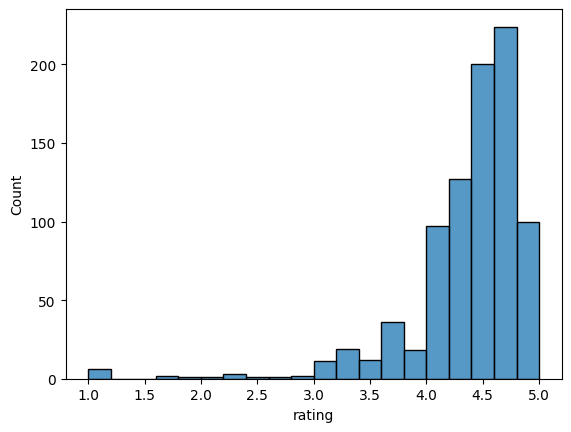

In [51]:
# Rating distribution
sns.histplot(lviv_df["rating"], bins=20)

In [52]:
# Check for suspicious values
print("\nRating range:", lviv_df["rating"].min(), "—", lviv_df["rating"].max())
print("Ratings below 2.0 (suspicious):")
print(lviv_df[lviv_df["rating"] < 2.0][["found_name", "rating", "reviews_count"]])


Rating range: 1.0 — 5.0
Ratings below 2.0 (suspicious):
                                  found_name  rating  reviews_count
248                               Skatertyna     1.0            1.0
329                                      Mak     1.0            1.0
431                               OMG! ASIA!     1.0            1.0
535                                 Odzhakhi     1.0            1.0
688                       Sandwich Bar Kebab     1.7           26.0
817                               OMG! ASIA!     1.0            1.0
847  Caucasus Kitchen, 3rd floor, food court     1.6           11.0
917                           Moya Pitseriya     1.8            5.0
937                           Smachnyy Vozyk     1.0            1.0


<Axes: xlabel='reviews_count', ylabel='Count'>

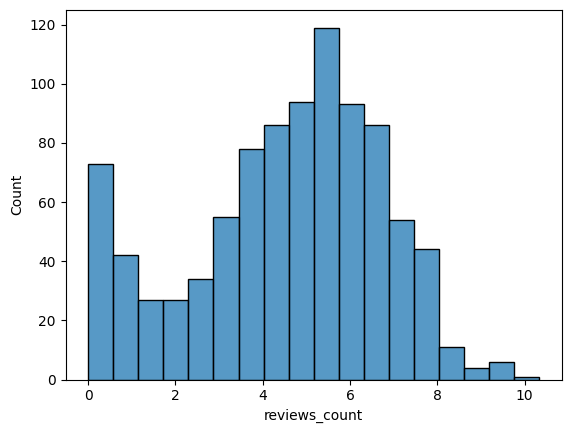

In [53]:
# Reviews count distribution
sns.histplot(np.log1p(lviv_df["reviews_count"]))

In [54]:
# Reviews count — heavy tail check
print("\nReviews count percentiles:")
print(lviv_df["reviews_count"].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))


Reviews count percentiles:
0.25      25.00
0.50     131.50
0.75     458.50
0.90    1350.10
0.95    2111.35
0.99    6641.20
Name: reviews_count, dtype: float64


In [55]:
# Low-confidence ratings
print("\nPlaces with 1-2 reviews:")
print(lviv_df[lviv_df["reviews_count"] <= 2][
    ["found_name", "rating", "reviews_count"]
].sort_values("rating", ascending=False).head(10))


Places with 1-2 reviews:
                            found_name  rating  reviews_count
62                    Mamtsya Nahoduye     5.0            2.0
68                           BrawnRoom     5.0            2.0
98                              U kuma     5.0            1.0
69                  Kukhnya V Korobtsi     5.0            1.0
80                            Smakolyk     5.0            1.0
89                          PizzaSpace     5.0            1.0
242                  Tartufo Trattoria     5.0            1.0
228  Orenda Prymishchen U Trts Laz 695     5.0            2.0
307                      Coffee go Hub     5.0            2.0
261                       MIRA Terrace     5.0            1.0


### **Bayesian Rating**

Bayesian rating adjusts each restaurant’s score toward the market average based on review volume.

This produces a more reliable ranking than raw rating alone.

In [56]:
# Calculate Bayesian Rating

# Average rating across all restaurants
C = lviv_df["rating"].mean()

# Minimum reviews threshold (75th percentile)
m = lviv_df["reviews_count"].quantile(0.75)

# Bayesian rating
lviv_df["bayesian_rating"] = (
    (lviv_df["reviews_count"] / (lviv_df["reviews_count"] + m)) * lviv_df["rating"]
    +
    (m / (lviv_df["reviews_count"] + m)) * C
)

In [57]:
# Compare rankings
print("Top 10 by Raw Rating")
display(
    lviv_df[["found_name", "rating", "reviews_count"]].sort_values(
        "rating", ascending=False).head(10)
)

Top 10 by Raw Rating


,found_name,rating,reviews_count
62,Mamtsya Nahoduye,5.0,2.0
749,MegaBite,5.0,6.0
65,Pekarnya Tsynamon,5.0,14.0
89,PizzaSpace,5.0,1.0
80,Smakolyk,5.0,1.0
69,Kukhnya V Korobtsi,5.0,1.0
68,BrawnRoom,5.0,2.0
124,Myasna Bochka,5.0,16.0
153,Farmajo Pekarnya,5.0,4.0
666,Sushi smak,5.0,6.0


In [58]:
print("Top 10 by Bayesian Rating")
display(
    lviv_df[["found_name", "rating", "reviews_count", "bayesian_rating"]]
    .sort_values("bayesian_rating", ascending=False).head(10)
)

Top 10 by Bayesian Rating


,found_name,rating,reviews_count,bayesian_rating
514,Babo Gardens,4.8,1884.0,4.710955
919,Fermali Tantuni,4.9,798.0,4.697502
445,Krayina Mriy Lviv 2,4.9,770.0,4.692887
165,EMILY Brooklyn Pizza,4.8,1456.0,4.691048
147,Sour,4.8,1404.0,4.688006
761,Mons Pius,4.7,5730.0,4.673703
903,Na Manhal Kebab House,4.8,1188.0,4.673314
381,Noa guest Emily,4.8,954.0,4.652327
303,New York Street Pizza,4.9,568.0,4.652130
974,EMILY Brooklyn Pizza,4.9,556.0,4.649198


Restaurants with few reviews are pulled closer to the market average,
while highly-reviewed restaurants remain close to their original rating.

## **10. Final Dataset Export**

The final dataset contains only analysis-ready columns and can be used for Tableau dashboards, marketplace coverage analysis, cuisine segmentation, and district-level geo-analysis.

In [59]:
# Select final analysis-ready columns

final_columns = [
    # Place identifiers
    "place_id",
    "found_name",

    # Location
    "address",
    "latitude",
    "longitude",
    "district",

    # Ratings
    "rating",
    "reviews_count",
    "has_rating",
    "bayesian_rating",

    # Price
    "price_level",

    # Business classification
    "business_model",
    "cuisine_type",

    # Opening hours
    "standard_opening_hours",
    "different_schedule_details",
    "closed_days",

    # Accessibility and service options
    "wheelchair",
    "delivery",
    "takeout",
    "dine_in",
    "glovo_available",

    # Links
    "maps_url"
]

lviv_df = lviv_df[[col for col in final_columns if col in lviv_df.columns]]

lviv_df.to_csv("lviv_restaurants_marketplace_dataset.csv", index=False, encoding="utf-8-sig")

In [60]:
print(f"Final dataset: {lviv_df.shape[0]:,} rows × {lviv_df.shape[1]} columns")

print("\nNew features created:")
print([
    "district",
    "has_rating",
    "bayesian_rating",
    "business_model",
    "cuisine_type",
    "standard_opening_hours",
    "different_schedule_details",
    "closed_days"
])

Final dataset: 934 rows × 22 columns

New features created:
['district', 'has_rating', 'bayesian_rating', 'business_model', 'cuisine_type', 'standard_opening_hours', 'different_schedule_details', 'closed_days']


**Final Output**

The final dataset contains cleaned, standardized, and enriched restaurant-level information ready for analysis and dashboarding.

**Final Columns**

| Column | Description |
|----------|----------|
| place_id | Unique Google Maps place identifier |
| found_name | Cleaned and standardized restaurant name |
| address | Cleaned restaurant address |
| latitude | Latitude coordinate |
| longitude | Longitude coordinate |
| district | Assigned Lviv district based on spatial mapping |
| rating | Google Maps rating |
| reviews_count | Number of Google Maps reviews |
| has_rating | Indicates whether rating information is available |
| bayesian_rating | Adjusted rating that accounts for review volume |
| price_level | Restaurant price category |
| business_model | Business format classification (Restaurant, Cafe, Bakery, etc.) |
| cuisine_type | Detected cuisine category or categories |
| standard_opening_hours | Most common weekly schedule |
| different_schedule_details | Days with non-standard opening hours |
| closed_days | Days when the restaurant is closed |
| wheelchair | Wheelchair accessibility information |
| delivery | Delivery availability |
| takeout | Takeout availability |
| dine_in | Dine-in availability |
| glovo_available | Whether the restaurant is available on Glovo |
| maps_url | Direct Google Maps URL |

## **Project Outcome**

The raw Google Maps dataset was transformed into an analysis-ready restaurant dataset.

Key transformations include:

- spatial filtering using official Lviv district boundaries;
- opening hours normalization;
- business model classification;
- cuisine type detection;
- restaurant name standardization;
- missing value assessment;
- service flag reconciliation;
- Bayesian rating calculation.

The resulting dataset can be used as a reliable input for exploratory analysis, dashboard development, marketplace coverage studies, and restaurant segmentation projects.